# LightGBM untuk Intrusion Detection — CSE-CIC-IDS2018

**Model:** LightGBM (Gradient Boosting)

| Komponen | Nilai |
|---|---|
| Input | 38 fitur |
| Algorithm | Gradient Boosted Decision Trees |
| scale_pos_weight | 3.2704 (dari preprocessing) |
| Holdout | Infiltration |
| Target F1 | ≥ 85% |
| Target FPR | ≤ 2% |

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Sel 1 — Setup

In [3]:
!pip install lightgbm --quiet

import os, gc, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, auc, roc_auc_score
)
from sklearn.model_selection import RandomizedSearchCV

np.random.seed(42)

dataset_path = "/content/drive/MyDrive/Colab Notebooks"

print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


---
## Sel 2 — Load Data

In [4]:
print('Memuat dataset...')
data = joblib.load(os.path.join(dataset_path, 'dataset_split.joblib'))

X_train = data['X_train'].astype('float32')
X_val   = data['X_val'].astype('float32')
X_test  = data['X_test'].astype('float32')
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']

lbl_train = data['label_train']
lbl_val   = data['label_val']
lbl_test  = data['label_test']

features         = data['features']
n_features       = data['n_features']
scale_pos_weight = data['scale_pos_weight']

del data
gc.collect()

ZERO_DAY_LABEL = 'Infiltration'

mask_no_inf_train = (lbl_train != ZERO_DAY_LABEL)
mask_no_inf_val   = (lbl_val   != ZERO_DAY_LABEL)

X_lgbm_train = X_train[mask_no_inf_train]
y_lgbm_train = y_train[mask_no_inf_train]
X_lgbm_val   = X_val[mask_no_inf_val]
y_lgbm_val   = y_val[mask_no_inf_val]

mask_infiltration_test = (lbl_test == ZERO_DAY_LABEL)
X_infiltration_test   = X_test[mask_infiltration_test].astype('float32')

print(f'Fitur              : {n_features}')
print(f'Train (tanpa Inf)  : {X_lgbm_train.shape[0]:,}')
print(f'Val   (tanpa Inf)  : {X_lgbm_val.shape[0]:,}')
print(f'Test               : {X_test.shape[0]:,}')
print(f'Infiltration test  : {X_infiltration_test.shape[0]:,}')
print(f'scale_pos_wt       : {scale_pos_weight:.4f}')

inf_train = (lbl_train == ZERO_DAY_LABEL).sum()
print(f'\nInfiltrasi di train: {inf_train:,} (disembunyikan)')
print('\nDistribusi test:')
for lbl, cnt in sorted(zip(*np.unique(lbl_test, return_counts=True)),
                       key=lambda x: -x[1]):
    print(f'  {lbl:<35} {cnt:>7,}')

Memuat dataset...
Fitur              : 38
Train (tanpa Inf)  : 8,099,910
Val   (tanpa Inf)  : 1,735,731
Test               : 1,759,848
Infiltration test  : 24,180
scale_pos_wt       : 3.2704

Infiltrasi di train: 112,760 (disembunyikan)

Distribusi test:
  Benign                              1,347,722
  DDOS attack-HOIC                    102,902
  DDoS attacks-LOIC-HTTP               86,428
  DoS attacks-Hulk                     69,287
  Bot                                  42,928
  FTP-BruteForce                       29,004
  SSH-Bruteforce                       28,139
  Infiltration                         24,180
  DoS attacks-SlowHTTPTest             20,983
  DoS attacks-GoldenEye                 6,227
  DoS attacks-Slowloris                 1,648
  DDOS attack-LOIC-UDP                    260
  Brute Force -Web                         92
  Brute Force -XSS                         35
  SQL Injection                            13


---
## Sel 3 — Hyperparameter Tuning (3% Data)

In [5]:
tune_idx = np.random.choice(len(X_lgbm_train), int(len(X_lgbm_train) * 0.03), replace=False)
X_tune   = X_lgbm_train[tune_idx]
y_tune   = y_lgbm_train[tune_idx]

param_dist = {
    'n_estimators'     : [200, 500, 1000],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'num_leaves'       : [31, 64, 128],
    'max_depth'        : [6, 10, 20, -1],
    'min_child_samples': [20, 50, 100],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [0, 0.1, 1.0],
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    verbosity=-1,
    random_state=42
)

print(f'Hyperparameter tuning pada {len(X_tune):,} sampel (3% data)...')
rscv = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rscv.fit(X_tune, y_tune)

print(f'\nParameter terbaik:')
for k, v in rscv.best_params_.items():
    print(f'  {k:<25} : {v}')
print(f'\nBest CV ROC-AUC: {rscv.best_score_:.4f}')

Hyperparameter tuning pada 242,997 sampel (3% data)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Parameter terbaik:
  subsample                 : 1.0
  reg_lambda                : 0
  reg_alpha                 : 0
  num_leaves                : 31
  n_estimators              : 1000
  min_child_samples         : 100
  max_depth                 : 6
  learning_rate             : 0.01
  colsample_bytree          : 1.0

Best CV ROC-AUC: 1.0000


---
## Sel 4 — Training LightGBM (Full Data)

In [6]:
best_p = rscv.best_params_.copy()
best_p.update({
    'objective'       : 'binary',
    'boosting_type'   : 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'n_jobs'          : -1,
    'verbosity'       : -1,
    'random_state'    : 42,
    'n_estimators'    : 2000,
})

print('Parameter training (dari tuning):')
for k, v in sorted(best_p.items()):
    print(f'  {k:<25} : {v}')

lgbm = lgb.LGBMClassifier(**best_p)

print(f'\nTraining LightGBM pada {X_lgbm_train.shape[0]:,} sampel (tanpa Infiltration)...')
start = time.time()

lgbm.fit(
    X_lgbm_train, y_lgbm_train,
    eval_set=[(X_lgbm_val, y_lgbm_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

elapsed = time.time() - start
print(f'\nTraining selesai dalam {elapsed:.1f} detik ({elapsed/60:.1f} menit)')
print(f'Best iteration: {lgbm.best_iteration_}')

lgbm.booster_.save_model(os.path.join(dataset_path, 'lgbm_model_final.txt'))
joblib.dump(lgbm, os.path.join(dataset_path, 'lgbm_model_final.joblib'))
print('Model tersimpan.')


Parameter training (dari tuning):
  boosting_type             : gbdt
  colsample_bytree          : 1.0
  learning_rate             : 0.01
  max_depth                 : 6
  min_child_samples         : 100
  n_estimators              : 2000
  n_jobs                    : -1
  num_leaves                : 31
  objective                 : binary
  random_state              : 42
  reg_alpha                 : 0
  reg_lambda                : 0
  scale_pos_weight          : 3.2703950365127468
  subsample                 : 1.0
  verbosity                 : -1

Training LightGBM pada 8,099,910 sampel (tanpa Infiltration)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.993243	valid_0's binary_logloss: 0.16632
[200]	valid_0's auc: 0.999471	valid_0's binary_logloss: 0.0785684
[300]	valid_0's auc: 0.999689	valid_0's binary_logloss: 0.0392976
[400]	valid_0's auc: 0.999824	valid_0's binary_logloss: 0.0201139
[500]	valid_0's auc: 0.999962	valid_0's binary_logloss: 0

---
## Sel 5 — Threshold Tuning

Prediksi probabilitas pada test set...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold optimal : 0.68
  F1  : 96.9416%
  FPR : 0.0115%


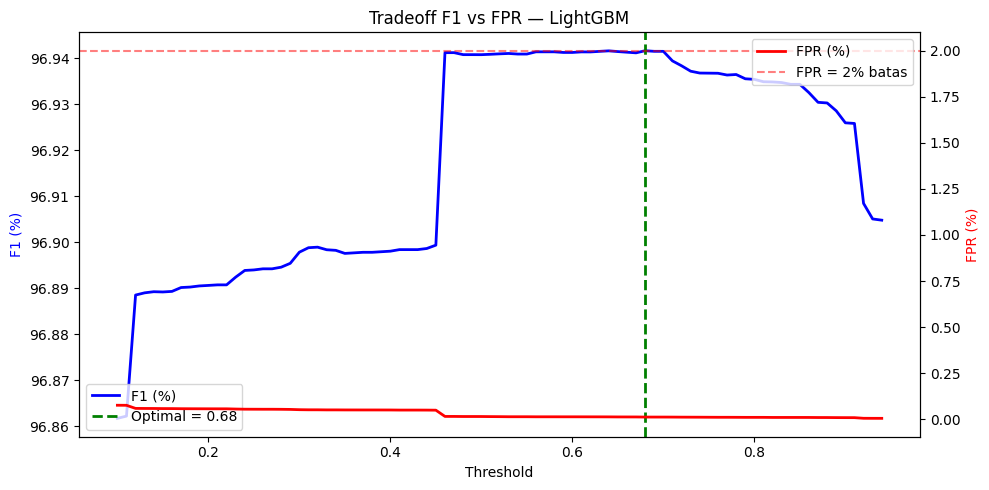

In [7]:
print('Prediksi probabilitas pada test set...')
y_probs = lgbm.predict_proba(X_test)[:, 1]

thresholds_sweep = np.arange(0.1, 0.95, 0.01)
results_thr = []
for thr in thresholds_sweep:
    y_p = (y_probs > thr).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, y_p).ravel()
    fpr_ = fp_ / (fp_ + tn_) * 100
    f1_  = f1_score(y_test, y_p) * 100
    results_thr.append({'threshold': thr, 'F1': f1_, 'FPR': fpr_})

df_thr = pd.DataFrame(results_thr)
valid  = df_thr[df_thr['FPR'] <= 2.0]

if len(valid) > 0:
    best = valid.loc[valid['F1'].idxmax()]
    THRESHOLD = best['threshold']
    print(f'Threshold optimal : {THRESHOLD:.2f}')
    print(f'  F1  : {best["F1"]:.4f}%')
    print(f'  FPR : {best["FPR"]:.4f}%')
else:
    THRESHOLD = 0.5
    print('Tidak ada threshold FPR<=2% — pakai 0.5')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_thr['threshold'], df_thr['F1'],  'b-', lw=2, label='F1 (%)')
ax2.plot(df_thr['threshold'], df_thr['FPR'], 'r-', lw=2, label='FPR (%)')
ax2.axhline(y=2.0, color='red', linestyle='--', alpha=0.5, label='FPR = 2% batas')
ax1.axvline(x=THRESHOLD, color='green', linestyle='--', lw=2,
            label=f'Optimal = {THRESHOLD:.2f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('F1 (%)', color='blue')
ax2.set_ylabel('FPR (%)', color='red')
ax1.set_title('Tradeoff F1 vs FPR — LightGBM')
ax1.legend(loc='lower left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

---
## Sel 6 — Evaluasi Binary

 EVALUASI LIGHTGBM — TEST SET
Accuracy                       98.6095%
F1-Score (Attack)              96.9416%
False Positive Rate (FPR)      0.0115%
Detection Rate (Recall)        94.1001%
True Positive                  387,811
False Negative                 24,315
False Positive                 155
True Negative                  1,347,567
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9823    0.9999    0.9910   1347722
      Attack     0.9996    0.9410    0.9694    412126

    accuracy                         0.9861   1759848
   macro avg     0.9909    0.9704    0.9802   1759848
weighted avg     0.9863    0.9861    0.9859   1759848

Target F1 >= 85%  : 96.94%   — ✓ TERCAPAI
Target FPR <= 2%  : 0.0115% — ✓ TERCAPAI


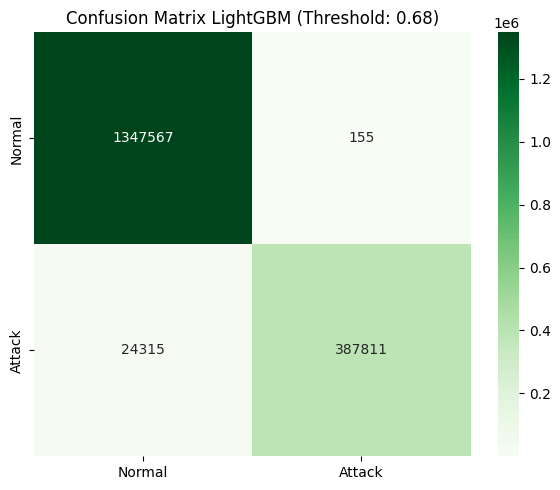

In [8]:
y_pred = (y_probs > THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_  = fp / (fp + tn) * 100
tpr_  = tp / (tp + fn) * 100
f1_   = f1_score(y_test, y_pred) * 100
acc_  = (tp + tn) / len(y_test) * 100

print('=' * 55)
print(' EVALUASI LIGHTGBM — TEST SET')
print('=' * 55)
print(f'{"Accuracy":<30} {acc_:.4f}%')
print(f'{"F1-Score (Attack)":<30} {f1_:.4f}%')
print(f'{"False Positive Rate (FPR)":<30} {fpr_:.4f}%')
print(f'{"Detection Rate (Recall)":<30} {tpr_:.4f}%')
print(f'{"True Positive":<30} {tp:,}')
print(f'{"False Negative":<30} {fn:,}')
print(f'{"False Positive":<30} {fp:,}')
print(f'{"True Negative":<30} {tn:,}')
print('-' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Normal', 'Attack'], digits=4))
f1_ok  = '✓ TERCAPAI' if f1_  >= 85 else '✗ BELUM'
fpr_ok = '✓ TERCAPAI' if fpr_ <=  2 else '✗ BELUM'
print(f'Target F1 >= 85%  : {f1_:.2f}%   — {f1_ok}')
print(f'Target FPR <= 2%  : {fpr_:.4f}% — {fpr_ok}')

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title(f'Confusion Matrix LightGBM (Threshold: {THRESHOLD:.2f})')
plt.tight_layout(); plt.show()

---
## Sel 7 — PR-AUC dan ROC-AUC

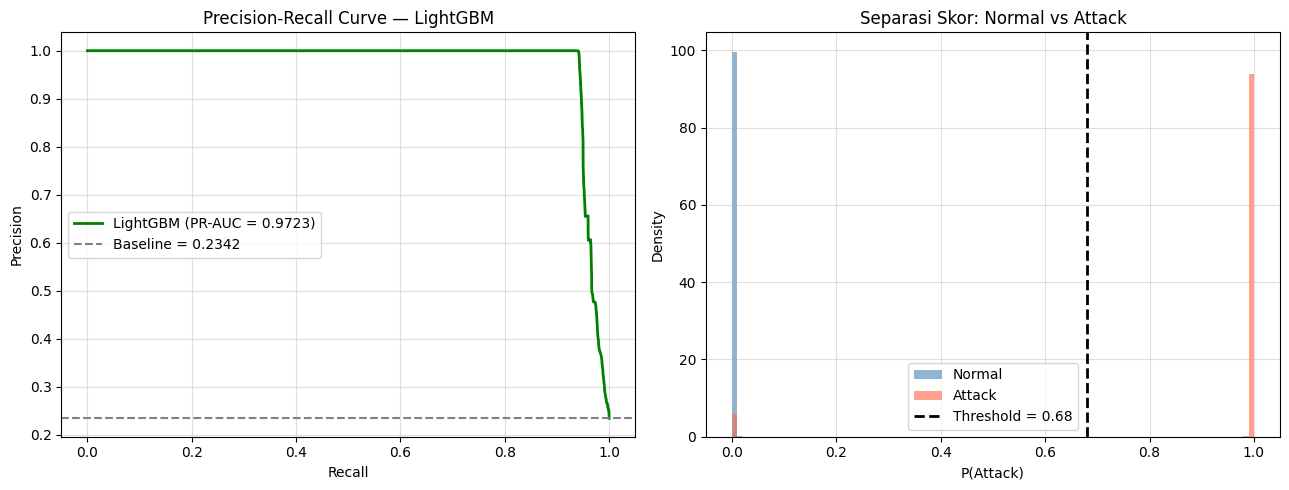

PR-AUC  : 0.9723
ROC-AUC : 0.9784


In [9]:
precision_, recall_, _ = precision_recall_curve(y_test, y_probs)
pr_auc  = auc(recall_, precision_)
roc_auc = roc_auc_score(y_test, y_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

baseline = y_test.mean()
axes[0].plot(recall_, precision_, color='green', lw=2,
             label=f'LightGBM (PR-AUC = {pr_auc:.4f})')
axes[0].axhline(y=baseline, color='gray', linestyle='--',
                label=f'Baseline = {baseline:.4f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — LightGBM')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].hist(y_probs[y_test==0], bins=100, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[1].hist(y_probs[y_test==1], bins=100, alpha=0.6,
             color='tomato', label='Attack', density=True)
axes[1].axvline(THRESHOLD, color='black', lw=2, linestyle='--',
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_xlabel('P(Attack)'); axes[1].set_ylabel('Density')
axes[1].set_title('Separasi Skor: Normal vs Attack')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(f'PR-AUC  : {pr_auc:.4f}')
print(f'ROC-AUC : {roc_auc:.4f}')

---
## Sel 8 — Feature Importance

Top 15 fitur terpenting:
          feature  importance
Init Fwd Win Byts       13591
    Flow Duration        4349
     Fwd IAT Mean        3877
Init Bwd Win Byts        3727
   Fwd Header Len        3445
 Fwd Seg Size Min        2558
      Flow Pkts/s        2501
   Bwd Header Len        2422
  Fwd Pkt Len Max        2149
     Flow IAT Max        1825
      Flow Byts/s        1686
 Fwd Pkt Len Mean        1583
      Pkt Len Max        1575
     Flow IAT Std        1417
      Fwd IAT Std        1308


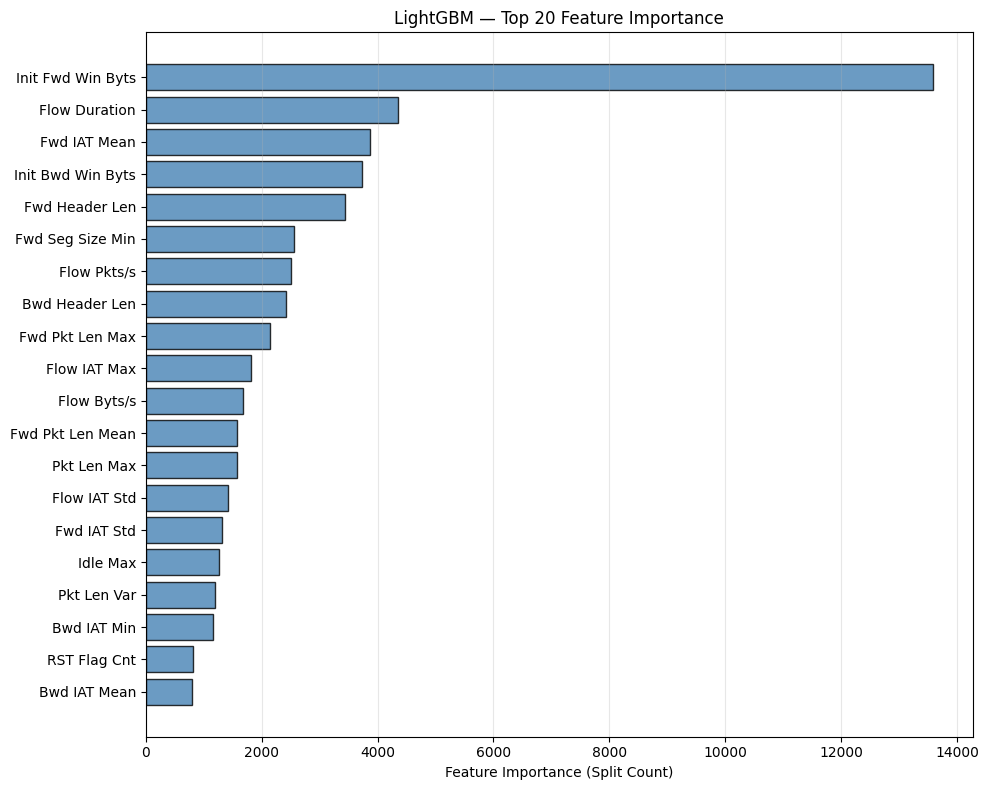

In [10]:
fi = pd.DataFrame({
    'feature'   : features,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 fitur terpenting:')
print(fi.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = fi.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('Feature Importance (Split Count)')
ax.set_title('LightGBM — Top 20 Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

---
## Sel 9 — Evaluasi Per Jenis Serangan

Detection Rate per Jenis Serangan — LightGBM (Holdout: Infiltration):
             Attack Type  Sampel  Terdeteksi Detection Rate (%) Mean P(Attack) Zero-Day
                     Bot   42928       42911              100.0         0.9988         
        Brute Force -Web      92          57               62.0         0.6799         
        Brute Force -XSS      35          29               82.9         0.8384         
        DDOS attack-HOIC  102902      102902              100.0         1.0000         
    DDOS attack-LOIC-UDP     260         260              100.0         0.9995         
  DDoS attacks-LOIC-HTTP   86428       86415              100.0         0.9997         
   DoS attacks-GoldenEye    6227        6227              100.0         0.9999         
        DoS attacks-Hulk   69287       69287              100.0         0.9999         
DoS attacks-SlowHTTPTest   20983       20983              100.0         1.0000         
   DoS attacks-Slowloris    1648        1542      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 SIMULASI ZERO-DAY: INFILTRATION (LightGBM)
Sampel Infiltration test  : 24,180
Terdeteksi                : 46 (0.19%)
Mean P(Attack)            : 0.0029
Mean P(Attack) Normal     : 0.0005
Threshold                 : 0.68


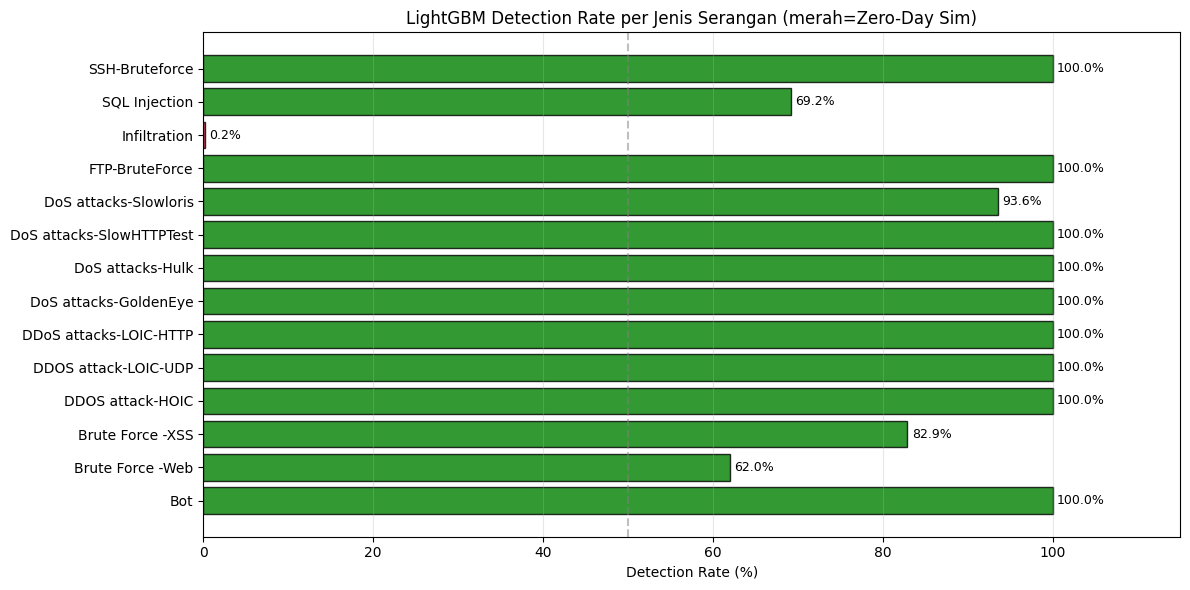

In [11]:
rows = []
for lbl in sorted(np.unique(lbl_test[y_test == 1])):
    mask = (lbl_test == lbl)
    if mask.sum() == 0: continue
    prob_lbl = y_probs[mask]
    pred_lbl = (prob_lbl > THRESHOLD).astype(int)
    n_t = mask.sum(); n_d = pred_lbl.sum()
    is_zd = 'YES' if lbl == ZERO_DAY_LABEL else ''
    rows.append({
        'Attack Type': lbl, 'Sampel': n_t, 'Terdeteksi': n_d,
        'Detection Rate (%)': f'{n_d/n_t*100:.1f}',
        'Mean P(Attack)': f'{prob_lbl.mean():.4f}',
        'Zero-Day': is_zd
    })

df_atk = pd.DataFrame(rows)
print('Detection Rate per Jenis Serangan — LightGBM (Holdout: Infiltration):')
print(df_atk.to_string(index=False))

# Zero-day Infiltration
probs_inf  = lgbm.predict_proba(X_infiltration_test)[:, 1]
pred_inf   = (probs_inf > THRESHOLD).astype(int)
dr_inf     = pred_inf.mean() * 100

print(f'\n{"="*55}')
print(f' SIMULASI ZERO-DAY: INFILTRATION (LightGBM)')
print(f'{"="*55}')
print(f'Sampel Infiltration test  : {len(pred_inf):,}')
print(f'Terdeteksi                : {pred_inf.sum():,} ({dr_inf:.2f}%)')
print(f'Mean P(Attack)            : {probs_inf.mean():.4f}')
print(f'Mean P(Attack) Normal     : {y_probs[y_test==0].mean():.4f}')
print(f'Threshold                 : {THRESHOLD:.2f}')


fig, ax = plt.subplots(figsize=(12, 6))
det_rates = [float(r['Detection Rate (%)']) for r in rows]
bar_colors = ['crimson' if r['Zero-Day'] == 'YES' else 'green' for r in rows]
bars = ax.barh([r['Attack Type'] for r in rows], det_rates,
               color=bar_colors, alpha=0.8, edgecolor='black')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Detection Rate (%)')
ax.set_title('LightGBM Detection Rate per Jenis Serangan (merah=Zero-Day Sim)')
for bar, val in zip(bars, det_rates):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 115); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

---
## Sel 10 — Ringkasan Final dan Simpan

In [12]:
print('=' * 55)
print(' RINGKASAN HASIL LightGBM — CSE-CIC-IDS2018')
print('=' * 55)
print(f'\n--- Konfigurasi ---')
print(f'  Algorithm        : LightGBM (GBDT)')
print(f'  Input            : {n_features} fitur')
print(f'  scale_pos_weight : {scale_pos_weight:.4f}')
print(f'  Best iteration   : {lgbm.best_iteration_}')
print(f'  Holdout          : Infiltration ')
print(f'  Threshold        : {THRESHOLD:.2f}')
print(f'\n--- Performa Deteksi ---')
print(f'  {"Accuracy":<30} {acc_:.4f}%')
print(f'  {"F1-Score (Attack)":<30} {f1_:.4f}%')
print(f'  {"False Positive Rate":<30} {fpr_:.4f}%')
print(f'  {"Detection Rate (Recall)":<30} {tpr_:.4f}%')
print(f'  {"PR-AUC":<30} {pr_auc:.4f}')
print(f'  {"ROC-AUC":<30} {roc_auc:.4f}')
f1_ok  = 'TERCAPAI' if f1_  >= 85 else 'BELUM'
fpr_ok = 'TERCAPAI' if fpr_ <=  2 else 'BELUM'
print(f'\n--- Target ---')
print(f'  F1 >= 85%  : {f1_:.2f}%   — {f1_ok}')
print(f'  FPR <= 2%  : {fpr_:.4f}% — {fpr_ok}')
print(f'\n--- Zero-Day (Infiltration Holdout) ---')
print(f'  Detection Rate : {dr_inf:.2f}%')
print(f'  Catatan        : LightGBM tidak pernah lihat Infiltration')

results_lgbm = {
    'model'                  : 'LightGBM',
    'f1'                     : f1_,
    'fpr'                    : fpr_,
    'recall'                 : tpr_,
    'accuracy'               : acc_,
    'pr_auc'                 : pr_auc,
    'roc_auc'                : roc_auc,
    'threshold'              : THRESHOLD,
    'zero_day_detection_rate': dr_inf,
    'zero_day_label'         : ZERO_DAY_LABEL
}
joblib.dump(results_lgbm,
            os.path.join(dataset_path, 'results_lgbm.joblib'))
joblib.dump(lgbm,
            os.path.join(dataset_path, 'lgbm_model_final.joblib'))
joblib.dump({'threshold': THRESHOLD, 'n_features': n_features,
             'features': features},
            os.path.join(dataset_path, 'lgbm_config.joblib'))

print('\n--- File Tersimpan ---')
for f in ['lgbm_model_final.joblib', 'lgbm_config.joblib', 'results_lgbm.joblib']:
    print(f'  v {f}')

 RINGKASAN HASIL LightGBM — CSE-CIC-IDS2018

--- Konfigurasi ---
  Algorithm        : LightGBM (GBDT)
  Input            : 38 fitur
  scale_pos_weight : 3.2704
  Best iteration   : 2000
  Holdout          : Infiltration 
  Threshold        : 0.68

--- Performa Deteksi ---
  Accuracy                       98.6095%
  F1-Score (Attack)              96.9416%
  False Positive Rate            0.0115%
  Detection Rate (Recall)        94.1001%
  PR-AUC                         0.9723
  ROC-AUC                        0.9784

--- Target ---
  F1 >= 85%  : 96.94%   — TERCAPAI
  FPR <= 2%  : 0.0115% — TERCAPAI

--- Zero-Day (Infiltration Holdout) ---
  Detection Rate : 0.19%
  Catatan        : LightGBM tidak pernah lihat Infiltration

--- File Tersimpan ---
  v lgbm_model_final.joblib
  v lgbm_config.joblib
  v results_lgbm.joblib
